# Image Caption Generator 2 - Flickr30k + VGG16

This notebook trains the machine learning part of an image caption generator using the Flickr30k dataset and VGG16 image features.

The model uses a CNN + LSTM approach:

- VGG16 extracts a feature vector from each image.
- An LSTM decoder learns to predict the next word in a caption.
- The trained model, tokenizer, and config are saved for the Streamlit app.


## 1. Kernel setup check

Run these first if VS Code is using a new kernel. The first cell prints the Python executable used by the notebook. The second cell installs the requirements into that same kernel.


In [1]:
import sys
print(sys.executable)


c:\image_caption_generator\.venv\Scripts\python.exe


In [2]:
# Run this if TensorFlow or another package is missing in the selected notebook kernel.
# After it finishes, restart the kernel and run the import cells again.
%pip install -r requirements.txt


  Using cached tensorboard-2.19.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---------- ----------------------------- 4.2/15.5 MB 25.0 MB/s eta 0:00:01
   ----------------------- ---------------- 9.2/15.5 MB 24.8 MB/s eta 0:00:01
   ------------------------------------ --- 14.2/15.5 MB 24.7 MB/s eta 0:00:01
   ---------------------------------------- 15.5/15.5 MB 23.8 MB/s  0:00:00
   ---------------------------------------- 0.0/11.5 MB ? eta -:--:--
   ---------------- ----------------------- 4.7/11.5 MB 22.0 MB/s eta 0:00:01
   ------------------ --------------------- 5.2/11.5 MB 22.7 MB/s eta 0:00:01
   ------------------------------ --------- 8.7/11.5 MB 13.8 MB/s eta 0:00:01
   ---------------------------------------- 11.5/11.5 MB 15.3 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.21.0 requires protobuf<8.0.0,>=6.31.1, but you have protobuf 5.29.6 which is incompatible.


## 2. Imports and warning setup


In [3]:
import os
import re
import pickle
import random
import warnings
from pathlib import Path
from collections import defaultdict

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, LSTM, Add
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

SEED_VALUE = 42
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)


## 3. Project and dataset paths




In [4]:
PROJECT_DIR = Path.cwd()
DATA_DIR = Path(r"C:\caption_generator2_pics&captions")
IMAGE_DIR = DATA_DIR / "flickr30k_images"
CAPTION_FILE = DATA_DIR / "captions.txt"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

FEATURE_FILE = ARTIFACT_DIR / "vgg16_features.pkl"
TOKENIZER_FILE = ARTIFACT_DIR / "caption_tokenizer_vgg16.pkl"
CONFIG_FILE = ARTIFACT_DIR / "caption_config_vgg16.pkl"
MODEL_FILE = ARTIFACT_DIR / "caption_model_vgg16.keras"

print("Project folder:", PROJECT_DIR)
print("Dataset folder:", DATA_DIR)
print("Caption file found:", CAPTION_FILE.exists())
print("Image count:", len(list(IMAGE_DIR.glob("*.jpg"))))


Project folder: c:\image_caption_generator2
Dataset folder: C:\caption_generator2_pics&captions
Caption file found: True
Image count: 31782


## 4. Load and clean Flickr30k captions

Flickr30k captions are stored with columns: image_name, comment_number, and comment.


In [5]:
def clean_caption_text(raw_text: str) -> str:
    text = str(raw_text).lower().strip()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return f"startseq {text} endseq"

caption_data = pd.read_csv(CAPTION_FILE)
caption_data.columns = [column.strip().lower() for column in caption_data.columns]
caption_data = caption_data.rename(columns={"image_name": "image", "comment": "caption"})
caption_data["caption_clean"] = caption_data["caption"].apply(clean_caption_text)
caption_data["image_path"] = caption_data["image"].apply(lambda filename: IMAGE_DIR / filename)
caption_data = caption_data[caption_data["image_path"].apply(lambda path: path.exists())].reset_index(drop=True)

captions_by_image = defaultdict(list)
for row in caption_data.itertuples(index=False):
    captions_by_image[row.image].append(row.caption_clean)

image_names = sorted(captions_by_image.keys())
caption_texts = caption_data["caption_clean"].tolist()

print("Caption rows:", len(caption_data))
print("Unique images:", len(image_names))
caption_data.head()


Caption rows: 158910
Unique images: 31782


,image,comment_number,caption,caption_clean,image_path
0,10002456.jpg,0,Several men in hard hats are operating a giant...,startseq several men in hard hats are operatin...,C:\caption_generator2_pics&captions\flickr30k_...
1,10002456.jpg,1,Workers look down from up above on a piece of ...,startseq workers look down from up above on a ...,C:\caption_generator2_pics&captions\flickr30k_...
2,10002456.jpg,2,Two men working on a machine wearing hard hats .,startseq two men working on a machine wearing ...,C:\caption_generator2_pics&captions\flickr30k_...
3,10002456.jpg,3,Four men on top of a tall structure .,startseq four men on top of a tall structure e...,C:\caption_generator2_pics&captions\flickr30k_...
4,10002456.jpg,4,Three men on a large rig .,startseq three men on a large rig endseq,C:\caption_generator2_pics&captions\flickr30k_...


## 5. Optional subset for faster assignment runs

Flickr30k is much larger than Flickr8k. Leave `MAX_IMAGES_FOR_RUN = None` to use the full dataset. Set it to a smaller number such as 6000 if your computer needs a faster test run.


In [6]:
MAX_IMAGES_FOR_RUN = None

if MAX_IMAGES_FOR_RUN is not None:
    selected_images = image_names[:MAX_IMAGES_FOR_RUN]
    selected_caption_texts = []
    selected_caption_lookup = defaultdict(list)
    for image_name in selected_images:
        selected_caption_lookup[image_name] = captions_by_image[image_name]
        selected_caption_texts.extend(captions_by_image[image_name])
    image_names = selected_images
    captions_by_image = selected_caption_lookup
    caption_texts = selected_caption_texts

print("Images used for this run:", len(image_names))
print("Captions used for this run:", len(caption_texts))


Images used for this run: 31782
Captions used for this run: 158910


## 6. Preview one image and its captions


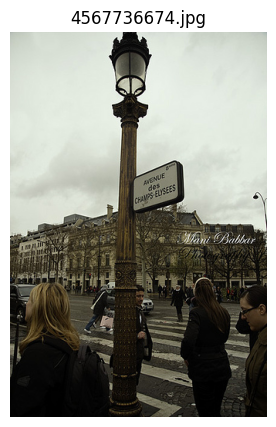

- a picture of people congregated around a street sign in french
- a busy intersection shows many people in france
- several people are standing on a street corner
- people standing at street corner in france
- a busy crosswalk in the city


In [7]:
example_name = random.choice(image_names)

plt.figure(figsize=(5, 5))
plt.imshow(load_img(IMAGE_DIR / example_name))
plt.axis("off")
plt.title(example_name)
plt.show()

for caption in captions_by_image[example_name]:
    print("-", caption.replace("startseq ", "").replace(" endseq", ""))


## 7. Split by image

Splitting by image keeps captions for the same picture from leaking across train, validation, and test sets.


In [8]:
train_images, test_images = train_test_split(
    image_names,
    test_size=0.20,
    random_state=SEED_VALUE,
    shuffle=True,
)

train_images, validation_images = train_test_split(
    train_images,
    test_size=0.10,
    random_state=SEED_VALUE,
    shuffle=True,
)

print("Train images:", len(train_images))
print("Validation images:", len(validation_images))
print("Test images:", len(test_images))


Train images: 22882
Validation images: 2543
Test images: 6357


## 8. Extract VGG16 image features

Features are saved to `artifacts/vgg16_features.pkl` so future runs can load them quickly.


In [9]:
def build_feature_extractor():
    base_model = VGG16(weights="imagenet")
    feature_model = Model(inputs=base_model.inputs, outputs=base_model.layers[-2].output)
    feature_model.trainable = False
    return feature_model


def load_image_batch(batch_names, target_size=(224, 224)):
    arrays = []
    valid_names = []
    for filename in batch_names:
        try:
            photo = load_img(IMAGE_DIR / filename, target_size=target_size)
            arrays.append(img_to_array(photo))
            valid_names.append(filename)
        except Exception as error:
            print(f"Skipping {filename}: {error}")
    if not arrays:
        return valid_names, np.empty((0, *target_size, 3), dtype="float32")
    return valid_names, preprocess_input(np.asarray(arrays, dtype="float32"))


def get_image_features(all_names, batch_size=32):
    if FEATURE_FILE.exists():
        with open(FEATURE_FILE, "rb") as file:
            feature_lookup = pickle.load(file)
        missing = [name for name in all_names if name not in feature_lookup]
        if not missing:
            print("Loaded cached VGG16 features:", len(feature_lookup))
            return feature_lookup
        print("Extracting missing features:", len(missing))
    else:
        feature_lookup = {}
        missing = list(all_names)

    feature_model = build_feature_extractor()
    for start in range(0, len(missing), batch_size):
        batch_names = missing[start:start + batch_size]
        valid_names, image_array = load_image_batch(batch_names)
        if len(valid_names) == 0:
            continue
        features = feature_model.predict(image_array, verbose=0)
        for filename, vector in zip(valid_names, features):
            feature_lookup[filename] = vector.astype("float32")
        print(f"Processed {min(start + batch_size, len(missing))}/{len(missing)} images")

    with open(FEATURE_FILE, "wb") as file:
        pickle.dump(feature_lookup, file)
    print("Saved features to", FEATURE_FILE)
    return feature_lookup

image_feature_map = get_image_features(image_names)
feature_length = next(iter(image_feature_map.values())).shape[0]
print("Feature length:", feature_length)


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 20s 0us/step
Processed 32/31782 images
Processed 64/31782 images
Processed 96/31782 images
Processed 128/31782 images
Processed 160/31782 images
Processed 192/31782 images
Processed 224/31782 images
Processed 256/31782 images
Processed 288/31782 images
Processed 320/31782 images
Processed 352/31782 images
Processed 384/31782 images
Processed 416/31782 images
Processed 448/31782 images
Processed 480/31782 images
Processed 512/31782 images
Processed 544/31782 images
Processed 576/31782 images
Processed 608/31782 images
Processed 640/31782 images
Processed 672/31782 images
Processed 704/31782 images
Processed 736/31782 images
Processed 768/31782 images
Processed 800/31782 images
Processed 832/31782 images
Processed 864/31782 images
Processed 896/31782 images
Processed 928/31782 images
Processed 960/31782 images
Processed 992/31782 images
Processed 1024/31782 images
Processed 1056/31782 images
Processed 1088/31782 images
Processed 1120/31782 images


## 9. Tokenize captions and save deployment artifacts


In [10]:
caption_tokenizer = Tokenizer(oov_token="<unk>")
caption_tokenizer.fit_on_texts(caption_texts)

vocab_size = len(caption_tokenizer.word_index) + 1
max_caption_length = max(len(caption.split()) for caption in caption_texts)

with open(TOKENIZER_FILE, "wb") as file:
    pickle.dump(caption_tokenizer, file)

caption_config = {
    "vocab_size": vocab_size,
    "max_caption_length": max_caption_length,
    "feature_length": feature_length,
    "image_size": (224, 224),
    "feature_extractor": "VGG16_fc2",
    "dataset": "Flickr30k",
    "start_token": "startseq",
    "end_token": "endseq",
}
with open(CONFIG_FILE, "wb") as file:
    pickle.dump(caption_config, file)

print("Vocabulary size:", vocab_size)
print("Maximum caption length:", max_caption_length)
print("Saved tokenizer and config in", ARTIFACT_DIR)


Vocabulary size: 18088
Maximum caption length: 80
Saved tokenizer and config in c:\image_caption_generator2\artifacts


## 10. Create training batches

Each sample uses an image feature vector plus a partial caption to predict the next word.


In [11]:
class CaptionSequence(Sequence):
    def __init__(self, selected_images, caption_lookup, feature_lookup, tokenizer, sequence_length, vocabulary_size, batch_size=128, shuffle=True):
        self.selected_images = list(selected_images)
        self.caption_lookup = caption_lookup
        self.feature_lookup = feature_lookup
        self.tokenizer = tokenizer
        self.sequence_length = sequence_length
        self.vocabulary_size = vocabulary_size
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.samples = []
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.samples) / self.batch_size))

    def on_epoch_end(self):
        self.samples = []
        for filename in self.selected_images:
            for caption in self.caption_lookup[filename]:
                token_ids = self.tokenizer.texts_to_sequences([caption])[0]
                for split_at in range(1, len(token_ids)):
                    self.samples.append((filename, token_ids[:split_at], token_ids[split_at]))
        if self.shuffle:
            random.shuffle(self.samples)

    def __getitem__(self, batch_index):
        batch_samples = self.samples[batch_index * self.batch_size:(batch_index + 1) * self.batch_size]
        image_batch = np.zeros((len(batch_samples), feature_length), dtype="float32")
        text_batch = np.zeros((len(batch_samples), self.sequence_length), dtype="int32")
        target_batch = np.zeros((len(batch_samples), self.vocabulary_size), dtype="float32")

        for row_index, (filename, partial_caption, next_word) in enumerate(batch_samples):
            image_batch[row_index] = self.feature_lookup[filename]
            text_batch[row_index] = pad_sequences([partial_caption], maxlen=self.sequence_length, padding="post")[0]
            target_batch[row_index] = to_categorical(next_word, num_classes=self.vocabulary_size)

        return {"image_features": image_batch, "caption_tokens": text_batch}, target_batch

train_sequence = CaptionSequence(train_images, captions_by_image, image_feature_map, caption_tokenizer, max_caption_length, vocab_size)
validation_sequence = CaptionSequence(validation_images, captions_by_image, image_feature_map, caption_tokenizer, max_caption_length, vocab_size, shuffle=False)

print("Train batches:", len(train_sequence))
print("Validation batches:", len(validation_sequence))


Train batches: 11880
Validation batches: 1331


## 11. Build the VGG16 + LSTM caption model


In [12]:
def build_caption_model(feature_count, vocabulary_count, sequence_length, embedding_size=256, hidden_size=256):
    image_input = Input(shape=(feature_count,), name="image_features")
    image_branch = Dropout(0.35)(image_input)
    image_branch = Dense(hidden_size, activation="relu")(image_branch)

    caption_input = Input(shape=(sequence_length,), name="caption_tokens")
    caption_branch = Embedding(vocabulary_count, embedding_size, mask_zero=True)(caption_input)
    caption_branch = Dropout(0.35)(caption_branch)
    caption_branch = LSTM(hidden_size)(caption_branch)

    merged = Add()([image_branch, caption_branch])
    merged = Dense(hidden_size, activation="relu")(merged)
    output_word = Dense(vocabulary_count, activation="softmax", name="next_word")(merged)

    model = Model(inputs=[image_input, caption_input], outputs=output_word)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

caption_model = build_caption_model(feature_length, vocab_size, max_caption_length)
caption_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ caption_tokens      │ (None, 80)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_features      │ (None, 4096)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 80, 256)   │  4,630,528 │ caption_tokens[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4096)      │          0 │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 80, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 80)        │          0 │ caption_tokens[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  1,048,832 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ next_word (Dense)   │ (None, 18088)     │  4,648,616 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,919,080 (41.65 MB)

 Trainable params: 10,919,080 (41.65 MB)

 Non-trainable params: 0 (0.00 B)

## 12. Train the model

Flickr30k + VGG16 can take a while. Start with 10 epochs, then increase if you want better captions and have time.


In [13]:
EPOCHS_TO_RUN = 10

callbacks = [
    ModelCheckpoint(MODEL_FILE, monitor="val_loss", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]

history = caption_model.fit(
    train_sequence,
    validation_data=validation_sequence,
    epochs=EPOCHS_TO_RUN,
    callbacks=callbacks,
)

caption_model.save(MODEL_FILE)
print("Saved model to", MODEL_FILE)


Epoch 1/10
11880/11880 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.2890 - loss: 4.2718
Epoch 1: val_loss improved from None to 3.57422, saving model to c:\image_caption_generator2\artifacts\caption_model_vgg16.keras

Epoch 1: finished saving model to c:\image_caption_generator2\artifacts\caption_model_vgg16.keras
11880/11880 ━━━━━━━━━━━━━━━━━━━━ 3235s 272ms/step - accuracy: 0.3220 - loss: 3.8868 - val_accuracy: 0.3493 - val_loss: 3.5742 - learning_rate: 0.0010
Epoch 2/10
11880/11880 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.3562 - loss: 3.4006
Epoch 2: val_loss improved from 3.57422 to 3.48283, saving model to c:\image_caption_generator2\artifacts\caption_model_vgg16.keras

Epoch 2: finished saving model to c:\image_caption_generator2\artifacts\caption_model_vgg16.keras
11880/11880 ━━━━━━━━━━━━━━━━━━━━ 3226s 272ms/step - accuracy: 0.3577 - loss: 3.3979 - val_accuracy: 0.3610 - val_loss: 3.4828 - learning_rate: 0.0010
Epoch 3/10
11880/11880 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step

## 13. Plot training performance


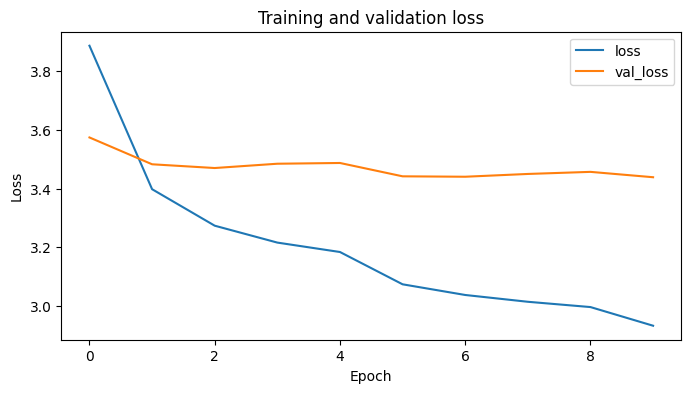

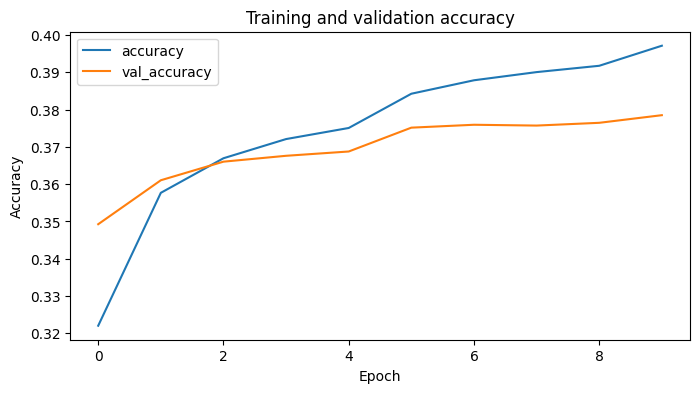

In [14]:
history_table = pd.DataFrame(history.history)
history_table[["loss", "val_loss"]].plot(figsize=(8, 4), title="Training and validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

if "accuracy" in history_table.columns:
    history_table[["accuracy", "val_accuracy"]].plot(figsize=(8, 4), title="Training and validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.show()


## 14. Generate captions


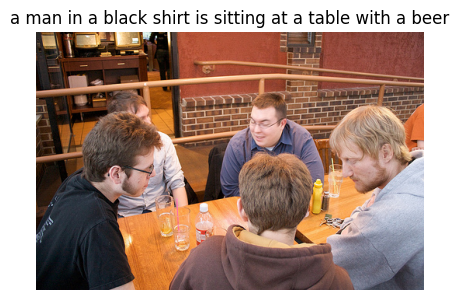

Predicted caption: a man in a black shirt is sitting at a table with a beer
Reference captions:
- a group of young men have finished their drinks while sitting at a table in a restaurant
- five men two of them wearing glasses talk at a table
- a group of male friends are having drinks at a table
- a group of twenty something men sit around a table
- boys night out after work


In [15]:
def word_from_id(tokenizer, token_id):
    return tokenizer.index_word.get(token_id)


def generate_caption(model, tokenizer, feature_vector, sequence_length):
    words = ["startseq"]
    for _ in range(sequence_length):
        token_ids = tokenizer.texts_to_sequences([" ".join(words)])[0]
        token_ids = pad_sequences([token_ids], maxlen=sequence_length, padding="post")
        probabilities = model.predict(
            {"image_features": np.asarray([feature_vector]), "caption_tokens": token_ids},
            verbose=0,
        )
        predicted_id = int(np.argmax(probabilities))
        predicted_word = word_from_id(tokenizer, predicted_id)
        if predicted_word is None:
            break
        words.append(predicted_word)
        if predicted_word == "endseq":
            break
    return " ".join(words).replace("startseq", "").replace("endseq", "").strip()


def extract_feature_for_uploaded_image(image_path):
    feature_model = build_feature_extractor()
    photo = load_img(image_path, target_size=(224, 224))
    photo_array = img_to_array(photo)
    photo_array = np.expand_dims(photo_array, axis=0)
    photo_array = preprocess_input(photo_array)
    return feature_model.predict(photo_array, verbose=0)[0]

best_caption_model = load_model(MODEL_FILE)
preview_name = random.choice(test_images)
predicted_caption = generate_caption(best_caption_model, caption_tokenizer, image_feature_map[preview_name], max_caption_length)

plt.figure(figsize=(5, 5))
plt.imshow(load_img(IMAGE_DIR / preview_name))
plt.axis("off")
plt.title(predicted_caption)
plt.show()

print("Predicted caption:", predicted_caption)
print("Reference captions:")
for caption in captions_by_image[preview_name]:
    print("-", caption.replace("startseq ", "").replace(" endseq", ""))


## 15. Optional BLEU evaluation

BLEU is a quick text-overlap score. It is useful for comparing model versions, but it does not always match human judgment perfectly.


In [16]:
try:
    from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

    actual = []
    predicted = []
    smoothing = SmoothingFunction().method1

    for filename in test_images[:500]:
        references = [caption.replace("startseq ", "").replace(" endseq", "").split() for caption in captions_by_image[filename]]
        generated = generate_caption(best_caption_model, caption_tokenizer, image_feature_map[filename], max_caption_length).split()
        actual.append(references)
        predicted.append(generated)

    print("BLEU-1:", corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0), smoothing_function=smoothing))
    print("BLEU-2:", corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing))
except ImportError:
    print("Install nltk to run BLEU: %pip install nltk")


BLEU-1: 0.5019269307846462
BLEU-2: 0.31968147684656056


## 16. Streamlit deployment notes

After training, the Streamlit app should load:

- `artifacts/caption_model_vgg16.keras`
- `artifacts/caption_tokenizer_vgg16.pkl`
- `artifacts/caption_config_vgg16.pkl`

For an uploaded image, the app resizes it to 224x224, preprocesses it with VGG16 preprocessing, extracts the VGG16 `fc2` feature vector, and calls `generate_caption(...)`.
